# Phoneme Statistics Visualization
Interactive exploration of phoneme duration differences between Parkinson's Disease (PD) and Healthy Control (HC) speakers.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define Data Root relative to the notebook
DATA_ROOT = '../datalocal/PC-GITA_v260210_24kHz/'

# Add root directory to sys.path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from phoneme_evaluation.data_loader import load_all_data
from phoneme_evaluation.analyzer import calculate_stats, get_discriminative_phonemes

# Set visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the processed and filtered data
print('Loading data...')
df = load_all_data()
print(f'Total phoneme samples: {len(df)}')
df.head()

Loading data...
Loading metadata from C:\Users\smidl\smidl_local\work\FAU\dysarthric-TTS\datalocal\PC-GITA_v260210_24kHz\_metadata\PCGITAtoPD_mapping.csv...
Processing directories: ['ddk', 'monologue_split', 'readtext_split', 'sentences_cleaned', 'words_merged']
 - Found 150 files in ddk
 - Found 793 files in monologue_split
 - Found 550 files in readtext_split
 - Found 890 files in sentences_cleaned
 - Found 430 files in words_merged
Filtering technical tokens: ['<p:>', '<usb>', 'sil', 'sp', 'SIL', 'SP']
Filtering outliers with Z-threshold=3.0...
Total samples loaded: 98647
Total phoneme samples: 98647


,begin,duration_samples,phoneme,duration,begin_sec,speaker_id,task,file_stem,sex,age,hy,status
0,37104,1679,B,0.069958,1.546,004PD,ddk,004PD_S1_DDK1,M,65,2.0,PD
1,45744,1919,B,0.079958,1.906,004PD,ddk,004PD_S1_DDK1,M,65,2.0,PD
2,55104,2159,B,0.089958,2.296,004PD,ddk,004PD_S1_DDK1,M,65,2.0,PD
3,61104,1199,B,0.049958,2.546,005PD,ddk,005PD_S1_DDK1,F,66,2.0,PD
4,72384,959,B,0.039958,3.016,005PD,ddk,005PD_S1_DDK1,F,66,2.0,PD


## Global Statistics Summary
Comparing average phoneme durations across PD and HC groups.

### Outlier Filtering (Z-score Strategy)
To ensure the statistical integrity of the analysis, we apply **Z-score outlier filtering** with a threshold of **|Z| > 3.0**.

**Rationale:**
Automatic alignment tools (like webMAUS) can occasionally produce errors, especially with dysarthric speech, resulting in unnaturally long or short phoneme durations. 
By calculating the Z-score for each phoneme duration relative to its specific phoneme class, we remove samples that fall outside the **99.7% confidence interval** (the 3rd standard deviation).

- **Threshold:** 3.0 standard deviations
- **Scope:** Performed independently for each unique phoneme label across the entire corpus.
- **Goal:** Minimize the impact of technical alignment errors on the final PD vs HC classification and statistical summaries.

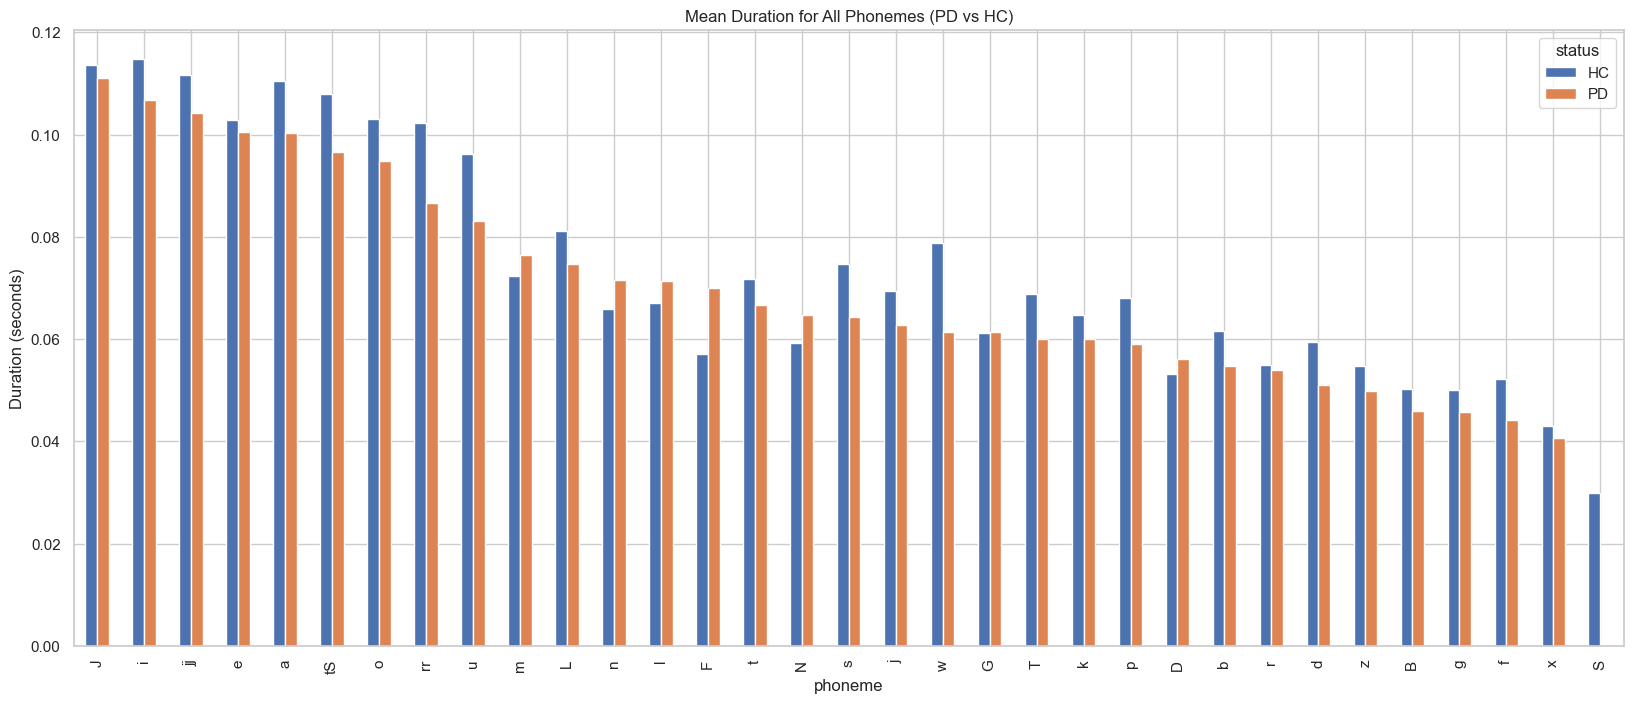

In [3]:
# Calculate stats grouped by Status
status_stats = calculate_stats(df, ['status'])
status_pivot = status_stats.pivot(index='phoneme', columns='status', values='mean_duration')

# Plot ALL phonemes by mean duration
status_pivot.sort_values(by='PD', ascending=False).plot(kind='bar', figsize=(20, 8))
plt.title('Mean Duration for All Phonemes (PD vs HC)')
plt.ylabel('Duration (seconds)')
plt.show()

## Wide Statistics Table
Phoneme duration and variation for each phoneme, stratified by status and sex.

In [4]:
from phoneme_evaluation.reporter import generate_wide_report
from pathlib import Path

# Filter technical tokens for the table summary to be clean
df_clean = load_all_data(filter_technical=True)
wide_report = generate_wide_report(df_clean, Path('../reports/phoneme_stats_wide.csv'))

# Display formatted table for all phonemes
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(wide_report.style.format(precision=4))

Loading metadata from C:\Users\smidl\smidl_local\work\FAU\dysarthric-TTS\datalocal\PC-GITA_v260210_24kHz\_metadata\PCGITAtoPD_mapping.csv...
Processing directories: ['ddk', 'monologue_split', 'readtext_split', 'sentences_cleaned', 'words_merged']
 - Found 150 files in ddk
 - Found 793 files in monologue_split
 - Found 550 files in readtext_split
 - Found 890 files in sentences_cleaned
 - Found 430 files in words_merged
Filtering technical tokens: ['<p:>', '<usb>', 'sil', 'sp', 'SIL', 'SP']
Filtering outliers with Z-threshold=3.0...
Total samples loaded: 98647
Wide report saved to ..\reports\phoneme_stats_wide.csv


,phoneme,All_mean,All_var,All_count,PD_mean,PD_var,PD_count,PD_M_mean,PD_M_var,PD_M_count,PD_F_mean,PD_F_var,PD_F_count,HC_mean,HC_var,HC_count,HC_M_mean,HC_M_var,HC_M_count,HC_F_mean,HC_F_var,HC_F_count
0,B,0.0481,0.0005,2333,0.0459,0.0005,1134.0000,0.0449,0.0005,557.0000,0.0468,0.0005,577.0000,0.0502,0.0006,1199,0.0517,0.0007,590.0000,0.0488,0.0005,609
1,D,0.0546,0.0012,2407,0.0561,0.0013,1184.0000,0.0554,0.0013,634.0000,0.0568,0.0014,550.0000,0.0532,0.0011,1223,0.0556,0.0012,631.0000,0.0506,0.0010,592
2,F,0.0635,0.0013,14,0.0700,0.0022,7.0000,0.0666,0.0010,3.0000,0.0725,0.0038,4.0000,0.0571,0.0005,7,0.0640,0.0004,5.0000,0.0400,0.0002,2
3,G,0.0612,0.0010,775,0.0613,0.0013,346.0000,0.0612,0.0016,181.0000,0.0615,0.0011,165.0000,0.0612,0.0008,429,0.0647,0.0008,210.0000,0.0578,0.0007,219
4,J,0.1125,0.0025,434,0.1111,0.0024,196.0000,0.0948,0.0019,97.0000,0.1271,0.0024,99.0000,0.1137,0.0026,238,0.1058,0.0029,119.0000,0.1215,0.0021,119
5,L,0.0781,0.0015,289,0.0747,0.0019,134.0000,0.0633,0.0016,70.0000,0.0872,0.0020,64.0000,0.0811,0.0011,155,0.0853,0.0013,85.0000,0.0760,0.0008,70
6,N,0.0616,0.0012,413,0.0647,0.0014,181.0000,0.0640,0.0011,95.0000,0.0655,0.0017,86.0000,0.0592,0.0010,232,0.0604,0.0011,93.0000,0.0584,0.0010,139
7,S,0.0300,nan,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.0300,nan,1,nan,nan,nan,0.0300,nan,1
8,T,0.0647,0.0012,1138,0.0601,0.0011,537.0000,0.0485,0.0007,256.0000,0.0706,0.0013,281.0000,0.0689,0.0012,601,0.0601,0.0008,266.0000,0.0758,0.0014,335
9,a,0.1045,0.0030,16728,0.1002,0.0028,9751.0000,0.0948,0.0026,4940.0000,0.1058,0.0029,4811.0000,0.1105,0.0032,6977,0.1066,0.0030,3518.0000,0.1146,0.0034,3459


### Phoneme-to-Word Examples (Spanish SAMPA)
To help interpret the results, here are examples of the discriminative phonemes in common Spanish words:

| Phoneme | Example Word | English Equivalent |
|---------|--------------|-------------------|
| **w**   | **hu**evo    | **w**et           |
| **f**   | **f**uego    | **f**ire          |
| **F**   | **f**uego (v) | labiodental fricative |
| **rr**  | pe**rr**o    | trilled **r**     |
| **p**   | **p**adre    | **p**apa          |
| **tS**  | **ch**ico    | **ch**urch        |
| **s**   | **s**ol      | **s**un           |
| **d**   | **d**edo     | **d**ad           |
| **T**   | **z**apato   | **th**ink         |
| **u**   | m**u**cho    | b**oo**t          |


## Discriminative Phonemes
Identifying phonemes with the most significant differences using Cohen's d.

In [5]:
top_phonemes = get_discriminative_phonemes(df, top_n=10)
print(f'Top 10 most discriminative phonemes: {top_phonemes}')

# Filter data for these phonemes
df_top = df[df['phoneme'].isin(top_phonemes)]

Top 10 most discriminative phonemes: ['w', 'f', 'F', 'rr', 'p', 'tS', 's', 'd', 'T', 'u']


## Duration Distributions (Boxplots)
Visualizing the variance and range for discriminative phonemes.

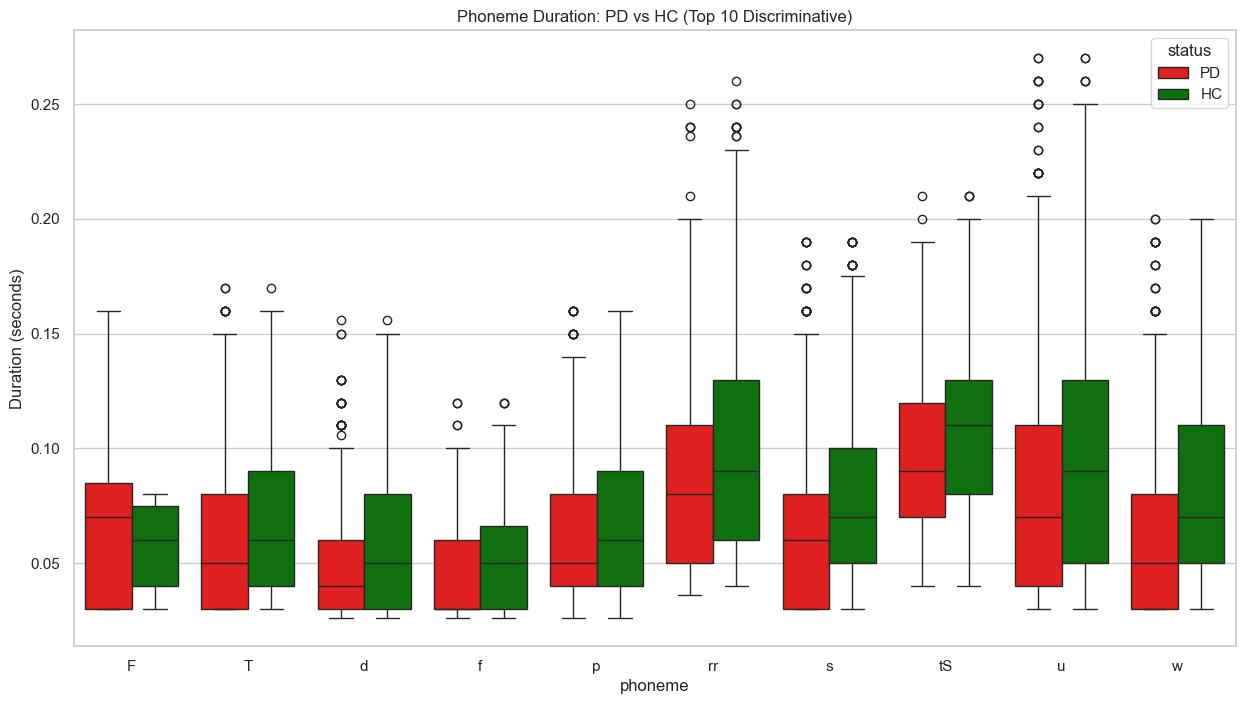

In [6]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_top, x='phoneme', y='duration', hue='status', palette={'HC': 'green', 'PD': 'red'})
plt.title('Phoneme Duration: PD vs HC (Top 10 Discriminative)')
plt.ylabel('Duration (seconds)')
plt.show()

### Understanding Cohen's d (Effect Size)
Cohen's d is an effect size used to indicate the **standardized difference** between two means.

**Equation:**

 d = \\frac{\\bar{x}_1 - \\bar{x}_2}{s_{pooled}} 

Where:
- $\\bar{x}_1$ and $\\bar{x}_2$ are the means of the PD and HC groups.
- {pooled}$ is the pooled standard deviation.

**Interpretation in our context:**
- **Positive d (> 0):** The phoneme duration is **longer** in the PD group compared to HC.
- **Negative d (< 0):** The phoneme duration is **shorter** in the PD group compared to HC.

**Standard benchmarks:**
- **0.2:** Small effect
- **0.5:** Medium effect
- **0.8:** Large effect


## Duration Distributions (Boxplots) for All Phonemes
Phonemes are ordered by Cohen's d (most discriminative first).

Loading metadata from C:\Users\smidl\smidl_local\work\FAU\dysarthric-TTS\datalocal\PC-GITA_v260210_24kHz\_metadata\PCGITAtoPD_mapping.csv...
Processing directories: ['ddk', 'monologue_split', 'readtext_split', 'sentences_cleaned', 'words_merged']
 - Found 150 files in ddk
 - Found 793 files in monologue_split
 - Found 550 files in readtext_split
 - Found 890 files in sentences_cleaned
 - Found 430 files in words_merged
Filtering technical tokens: ['<p:>', '<usb>', 'sil', 'sp', 'SIL', 'SP']
Filtering outliers with Z-threshold=3.0...
Total samples loaded: 98647


a:\work\FAU\dysarthric-TTS\phoneme_evaluation\visualizer.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_stats, x="phoneme", y="cohens_d", ax=ax_d, palette="vlag")


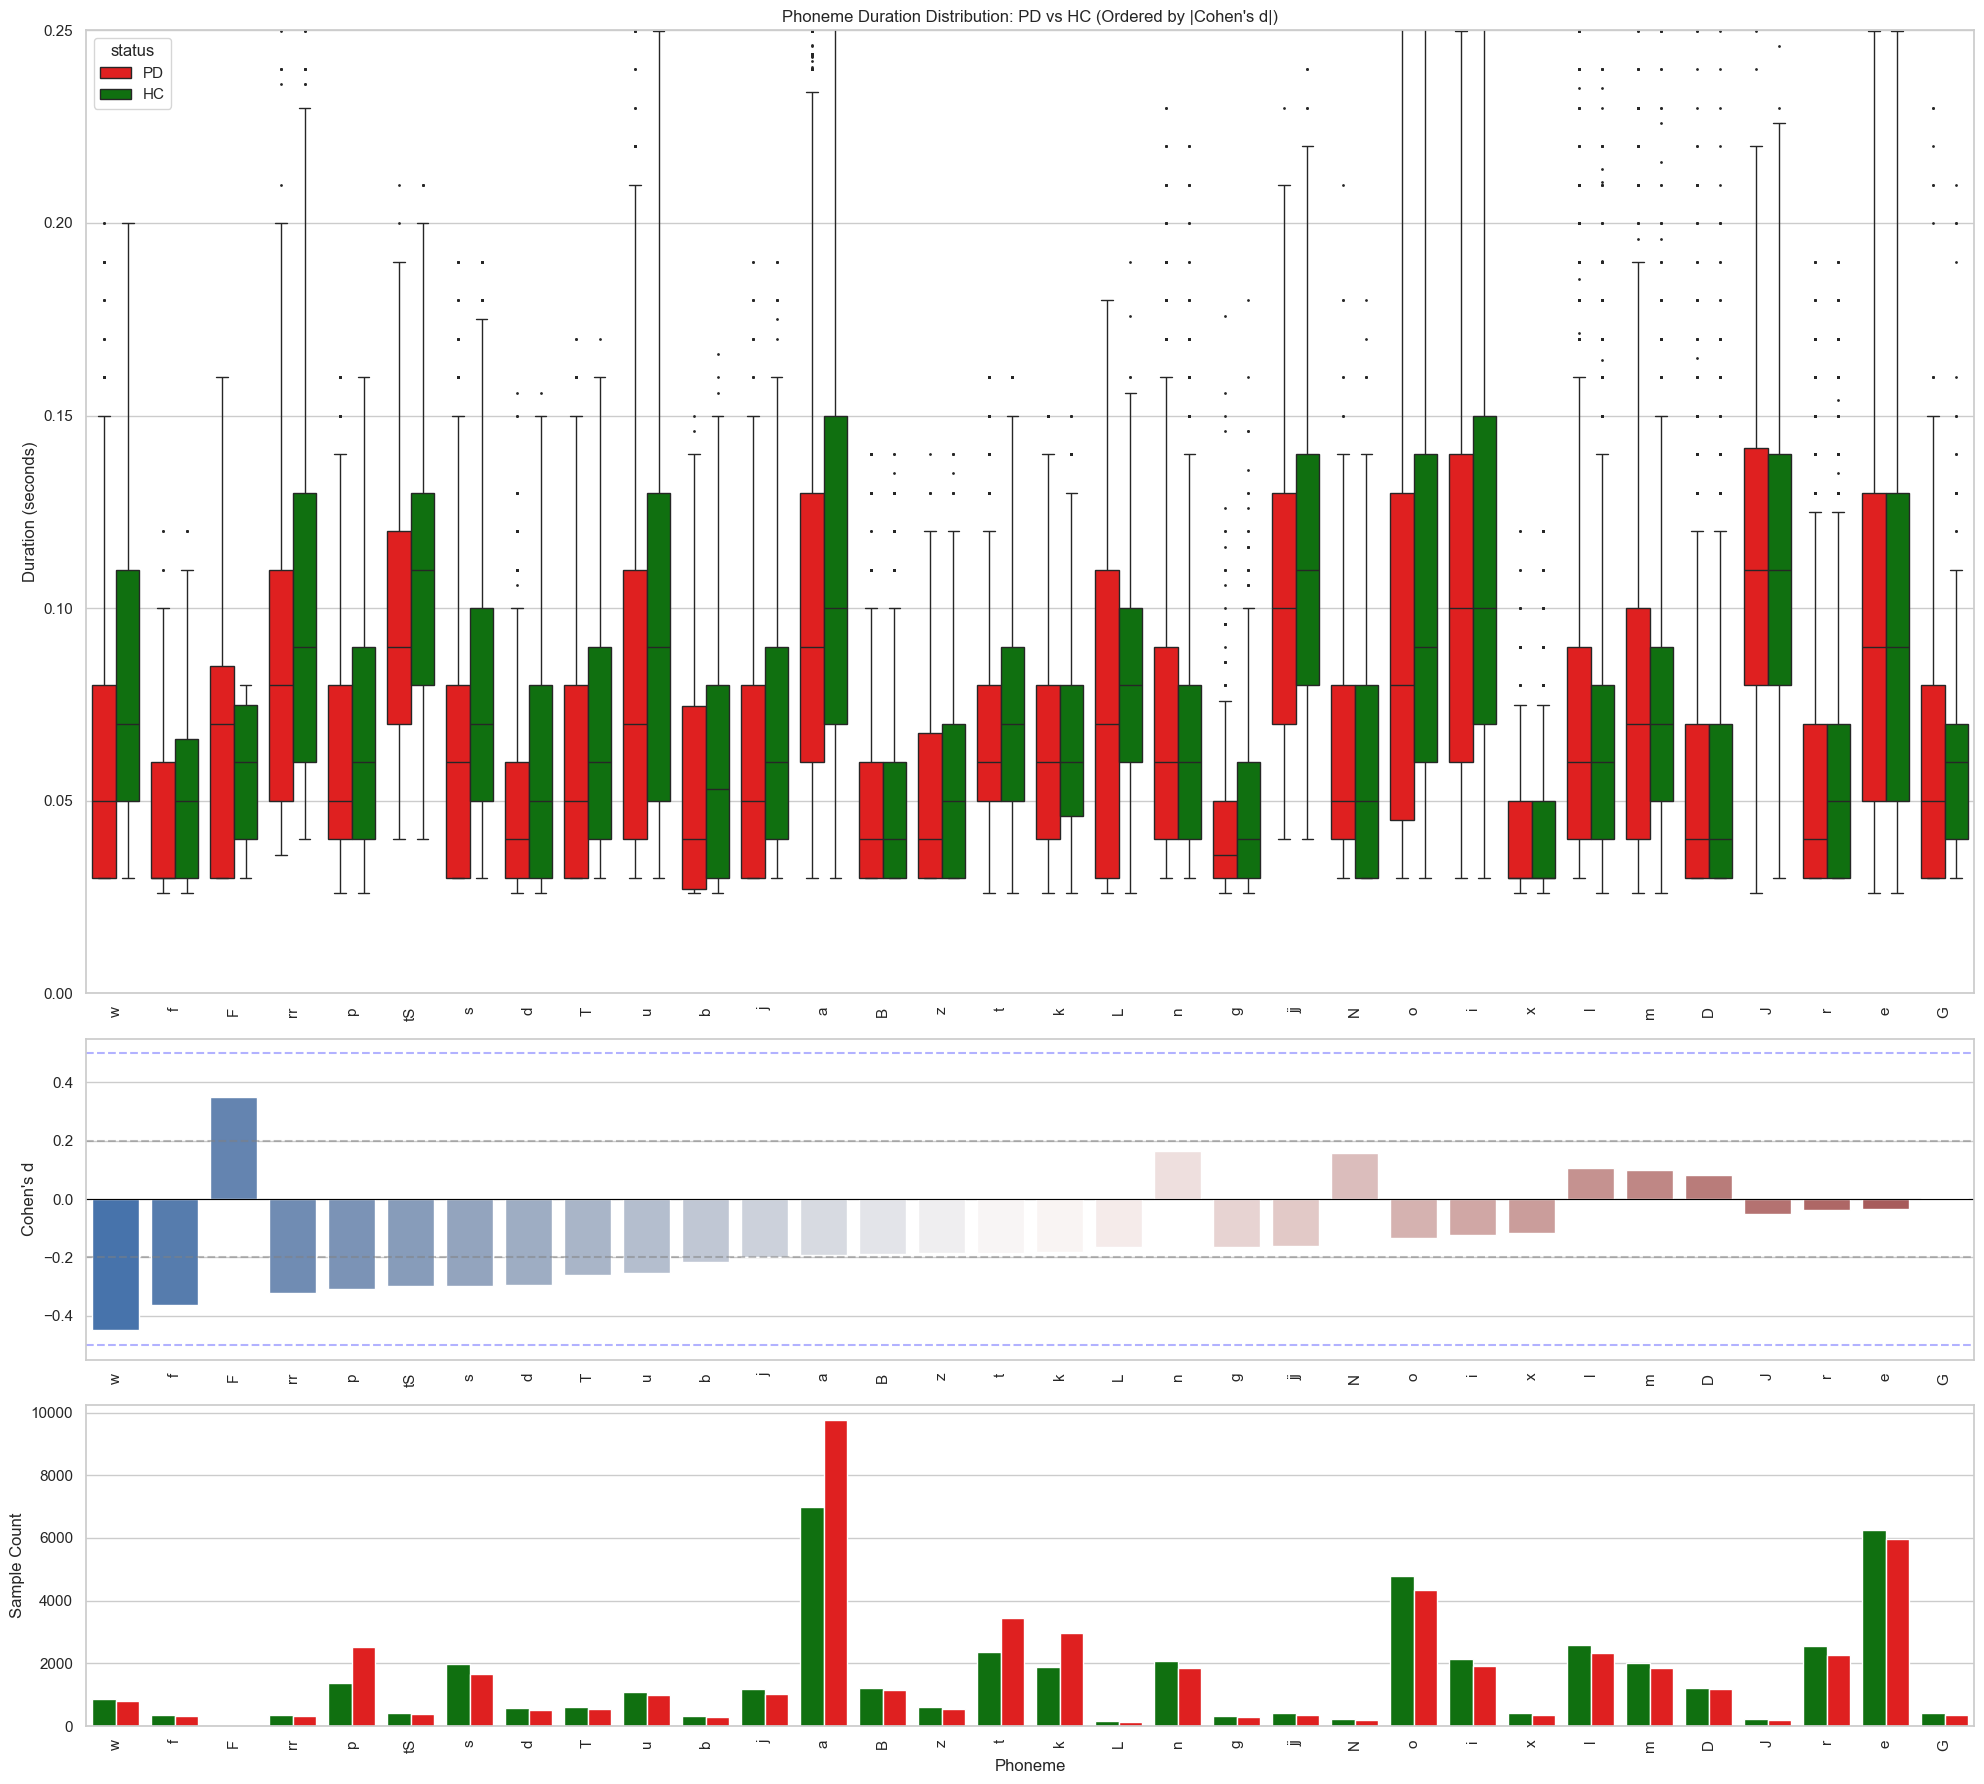

In [7]:
from phoneme_evaluation.visualizer import plot_all_phonemes_boxplot
from pathlib import Path

# Filter technical tokens before plotting for clarity
df_clean = load_all_data(filter_technical=True)
plot_path = Path('../reports/plots/phonemes_all_boxplot_notebook.png')
plot_all_phonemes_boxplot(df_clean, plot_path)

from IPython.display import Image
Image(filename=str(plot_path))

## Stratified Duration Distributions (Boxplots) for All Phonemes
Phonemes are ordered by Cohen's d. Groups: HC Male, HC Female, PD Male, PD Female.

Loading metadata from C:\Users\smidl\smidl_local\work\FAU\dysarthric-TTS\datalocal\PC-GITA_v260210_24kHz\_metadata\PCGITAtoPD_mapping.csv...
Processing directories: ['ddk', 'monologue_split', 'readtext_split', 'sentences_cleaned', 'words_merged']
 - Found 150 files in ddk
 - Found 793 files in monologue_split
 - Found 550 files in readtext_split
 - Found 890 files in sentences_cleaned
 - Found 430 files in words_merged
Filtering technical tokens: ['<p:>', '<usb>', 'sil', 'sp', 'SIL', 'SP']
Filtering outliers with Z-threshold=3.0...
Total samples loaded: 98647


a:\work\FAU\dysarthric-TTS\phoneme_evaluation\visualizer.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_stats, x="phoneme", y="cohens_d", ax=ax_d, palette="vlag")


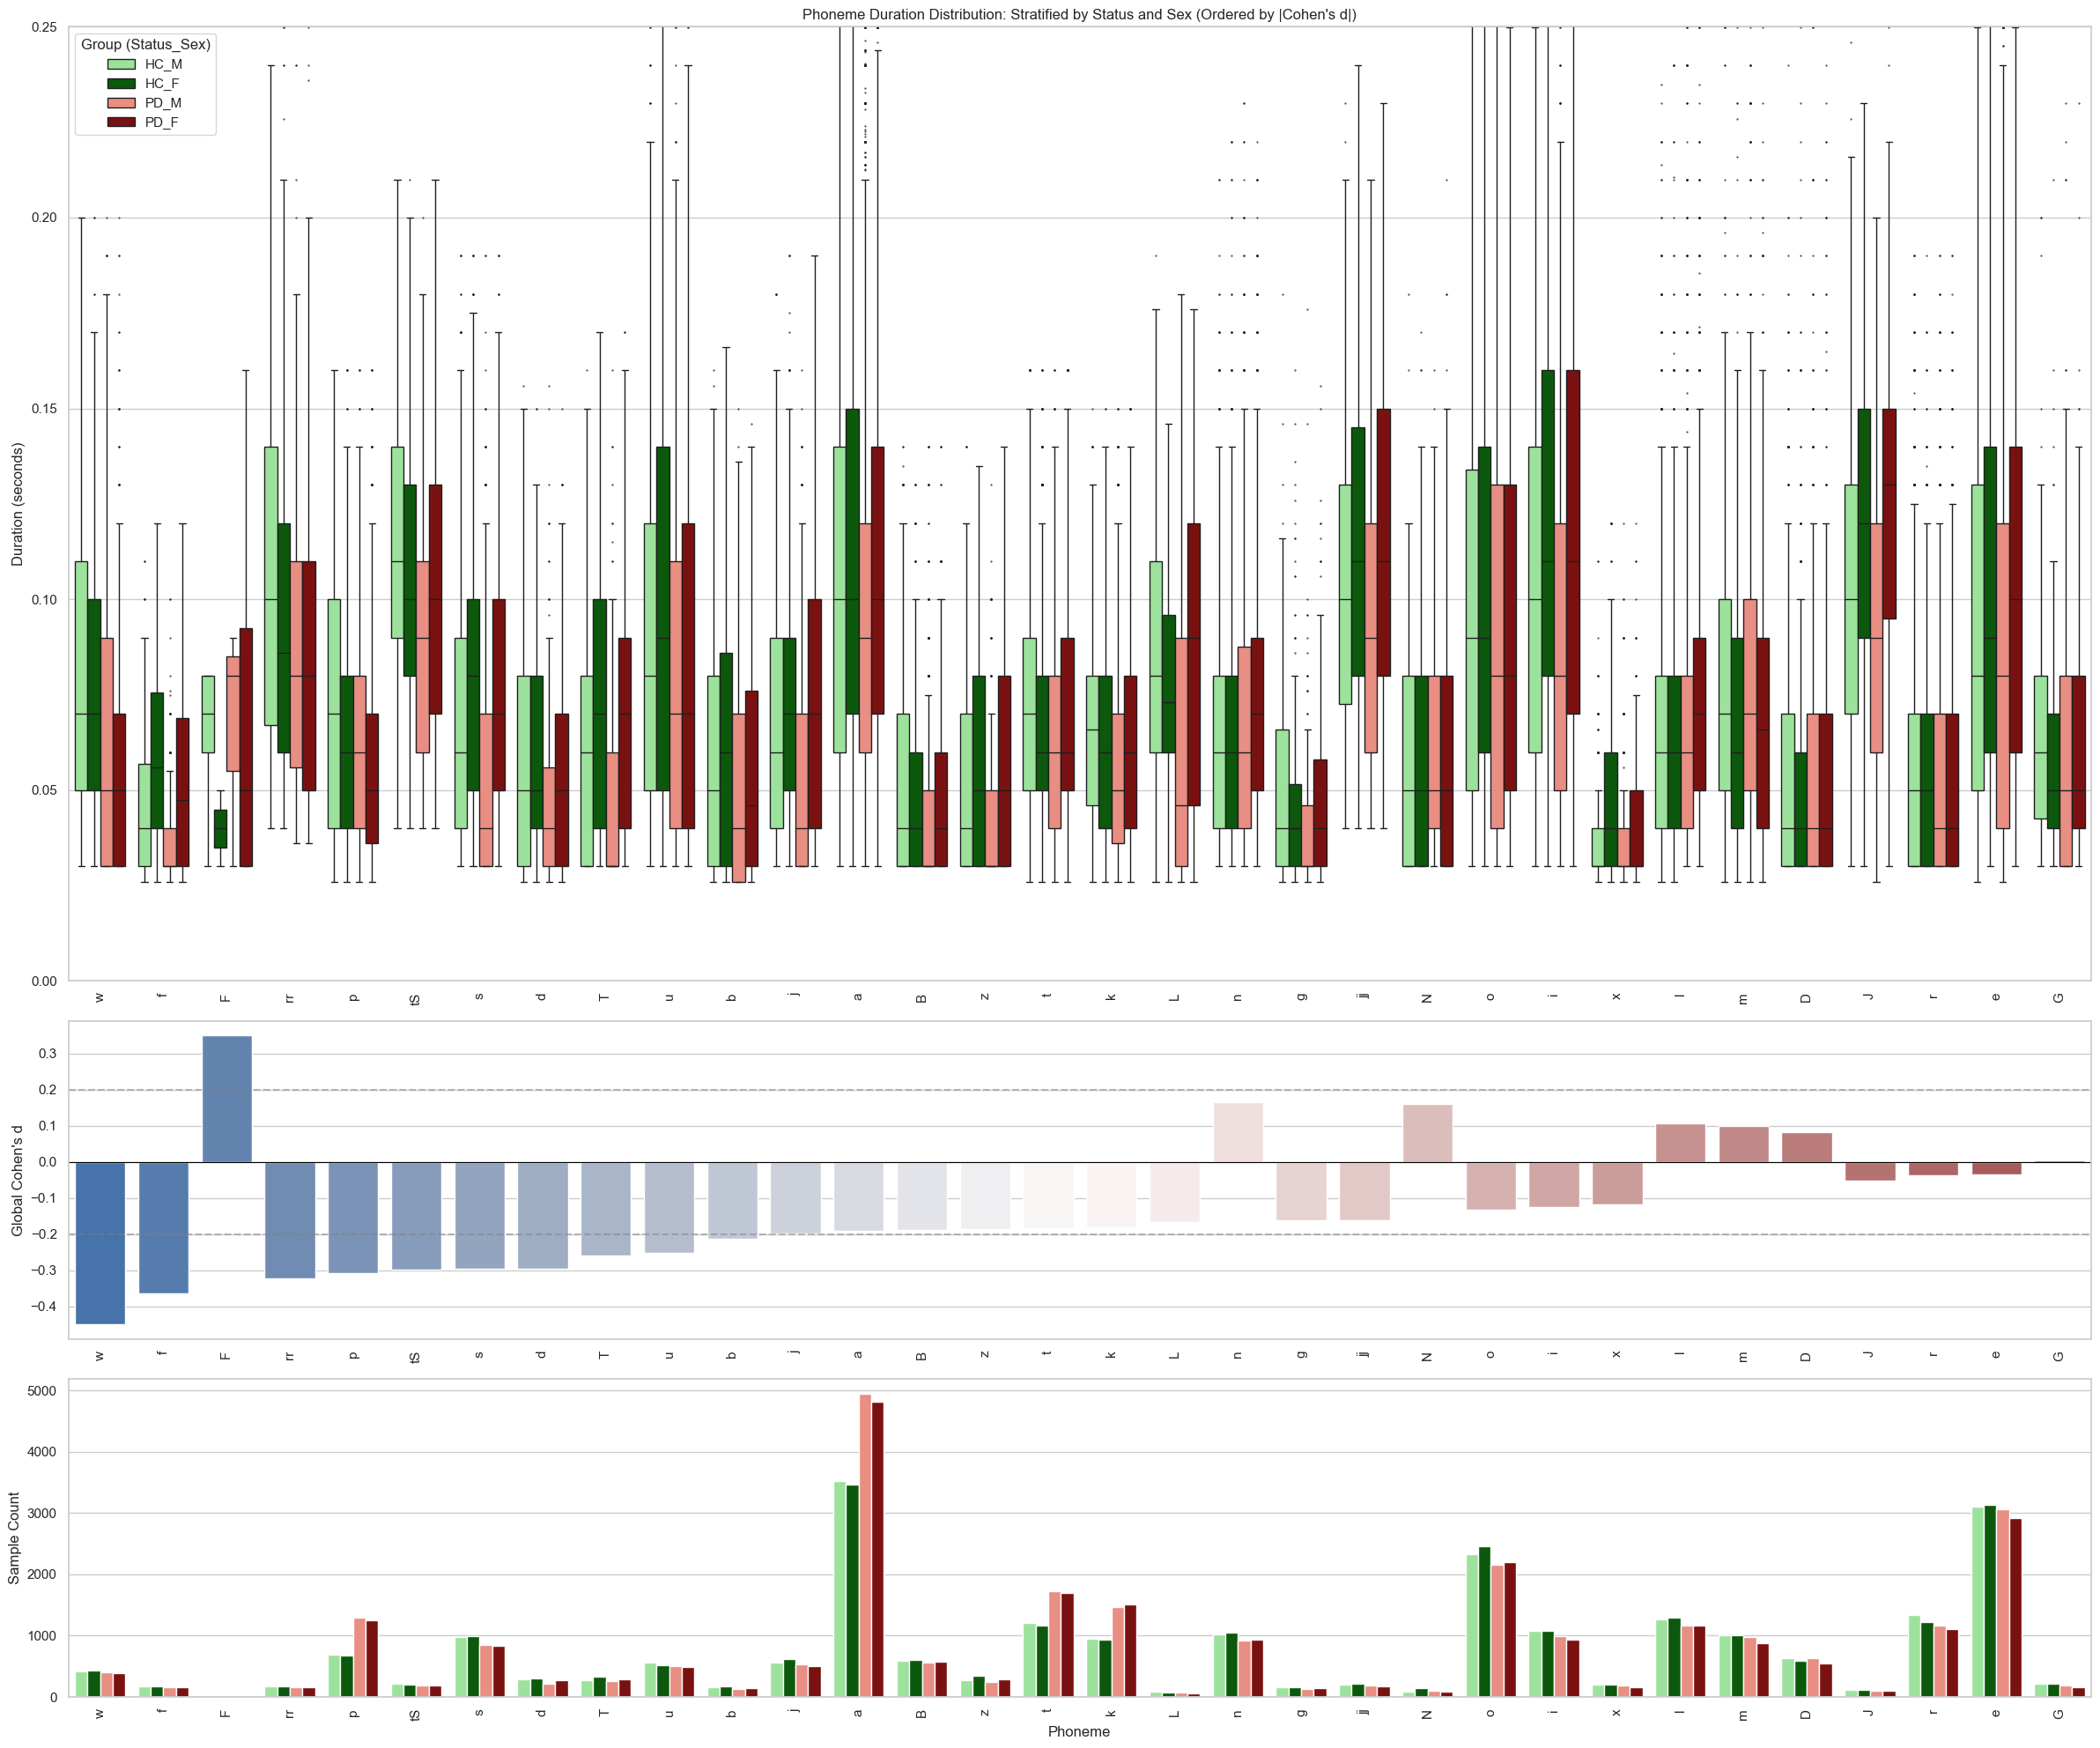

In [8]:
from phoneme_evaluation.visualizer import plot_stratified_phonemes_boxplot
from pathlib import Path

# Filter technical tokens before plotting
df_clean = load_all_data(filter_technical=True)
plot_path = Path('../reports/plots/phonemes_stratified_boxplot.png')
plot_stratified_phonemes_boxplot(df_clean, plot_path)

from IPython.display import Image
Image(filename=str(plot_path))

## Stratified Analysis: Status and Sex
Exploring how sex influences phoneme duration differences.

Phonemes with PD > HC: ['F', 'n']
Phonemes with PD < HC: ['w', 'rr']


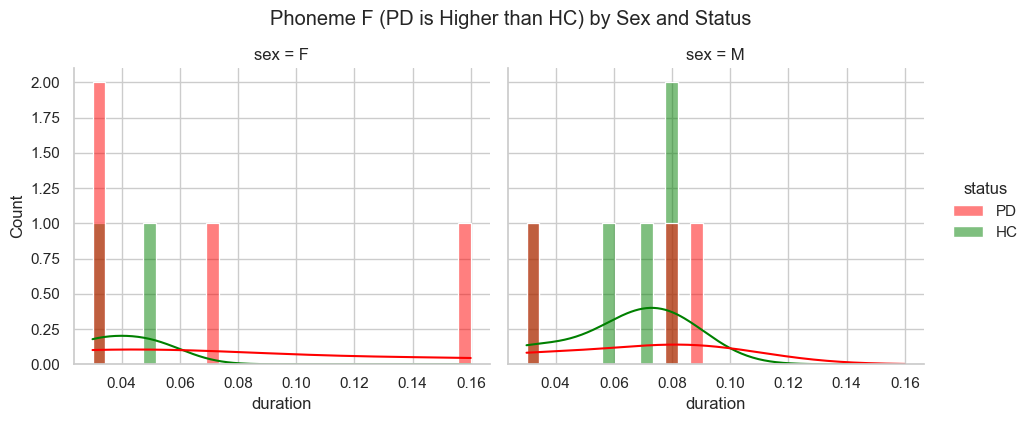

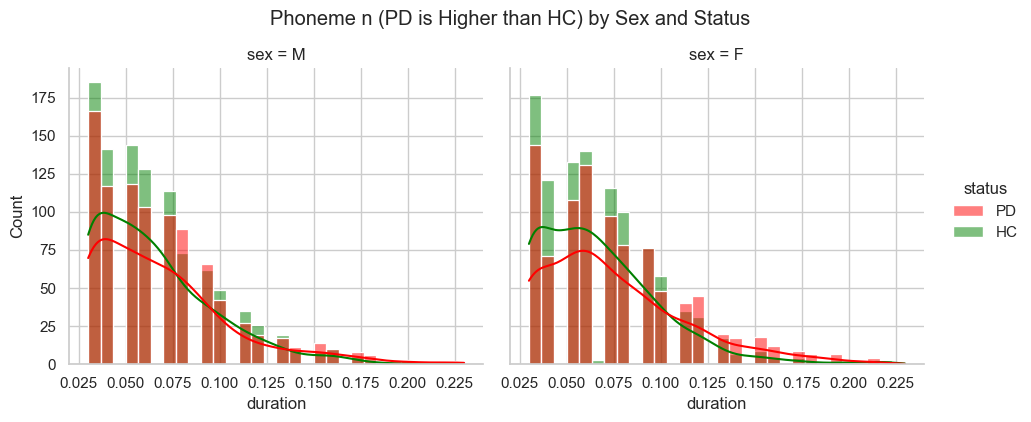

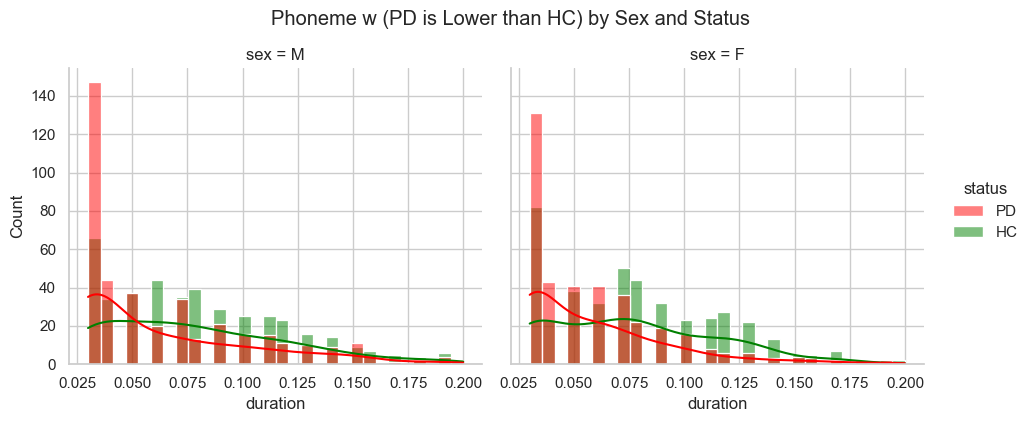

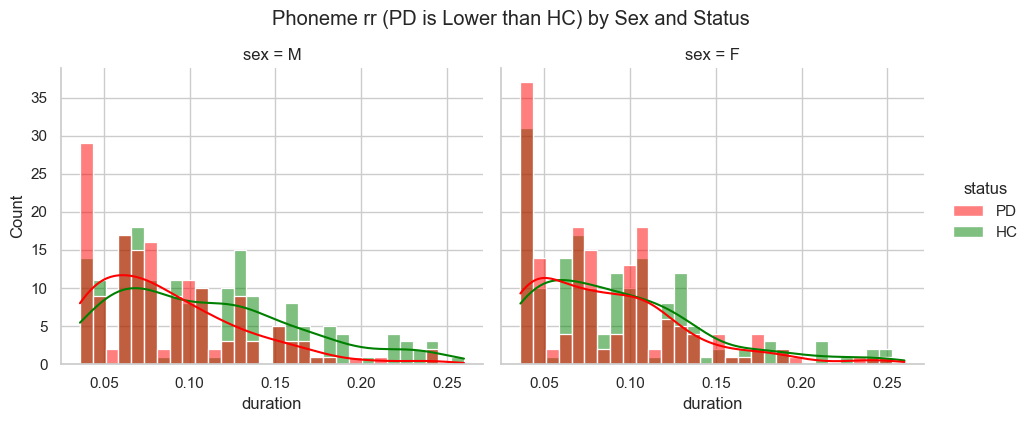

In [9]:
# Calculate mean differences between PD and HC to find specific examples
status_stats = df.groupby(['phoneme', 'status'])['duration'].mean().unstack()
status_stats['diff'] = status_stats['PD'] - status_stats['HC']

# Find phonemes where PD duration is HIGHER than HC (Positive difference)
pd_higher = status_stats.sort_values(by='diff', ascending=False).head(2).index.tolist()

# Find phonemes where PD duration is LOWER than HC (Negative difference)
pd_lower = status_stats.sort_values(by='diff', ascending=True).head(2).index.tolist()

examples = pd_higher + pd_lower
print('Phonemes with PD > HC:', pd_higher)
print('Phonemes with PD < HC:', pd_lower)

for ph in examples:
    data_ph = df[df['phoneme'] == ph]
    if data_ph.empty: continue
    
    # Using displot with kind='hist'
    g = sns.displot(
        data=data_ph, x='duration', hue='status', col='sex',
        kind='hist', kde=True, bins=30, height=4, aspect=1.2,
        palette={'HC': 'green', 'PD': 'red'}
    )
    
    diff_type = 'Higher' if ph in pd_higher else 'Lower'
    g.fig.suptitle(f'Phoneme {ph} (PD is {diff_type} than HC) by Sex and Status', y=1.05)
    plt.show()

## Task-Specific Analysis
Comparing phoneme duration profiles across different speaking tasks.

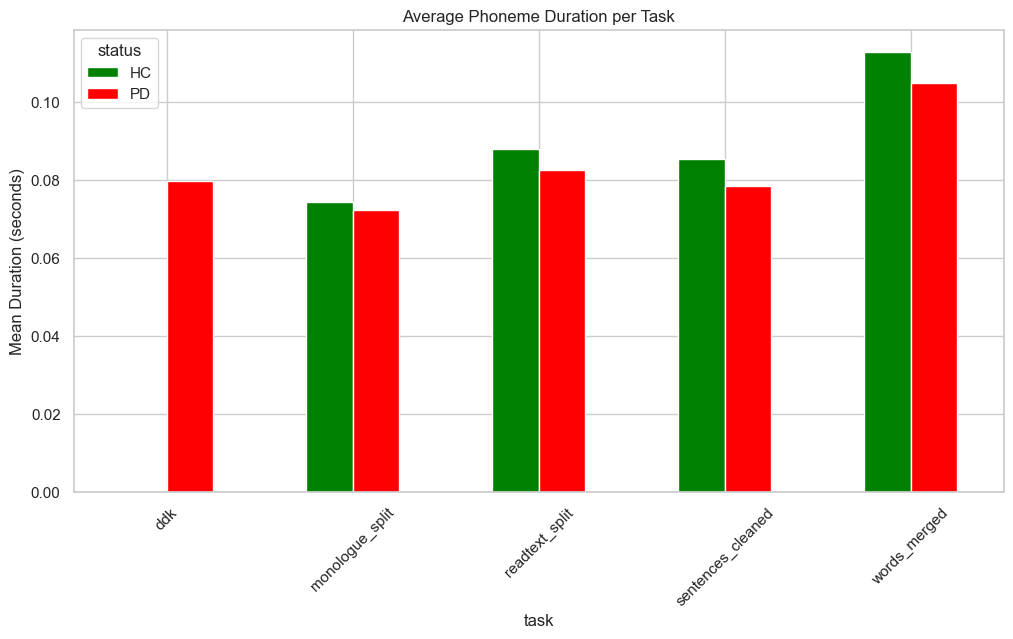

In [10]:
task_means = df.groupby(['task', 'status'])['duration'].mean().unstack()
task_means.plot(kind='bar', color=['green', 'red'])
plt.title('Average Phoneme Duration per Task')
plt.ylabel('Mean Duration (seconds)')
plt.xticks(rotation=45)
plt.show()

## Task-Specific Stratified Analysis
Detailed duration distributions (Boxplots + Cohen's d + Counts) for each task group separately.

Loading metadata from C:\Users\smidl\smidl_local\work\FAU\dysarthric-TTS\datalocal\PC-GITA_v260210_24kHz\_metadata\PCGITAtoPD_mapping.csv...
Processing directories: ['ddk', 'monologue_split', 'readtext_split', 'sentences_cleaned', 'words_merged']
 - Found 150 files in ddk
 - Found 793 files in monologue_split
 - Found 550 files in readtext_split
 - Found 890 files in sentences_cleaned
 - Found 430 files in words_merged
Filtering technical tokens: ['<p:>', '<usb>', 'sil', 'sp', 'SIL', 'SP']
Filtering outliers with Z-threshold=3.0...
Total samples loaded: 98647
Generating plots for task: ddk
Skipping display for ddk (plot not generated due to insufficient data)
Generating plots for task: monologue_split


a:\work\FAU\dysarthric-TTS\phoneme_evaluation\visualizer.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_stats, x="phoneme", y="cohens_d", ax=ax_d, palette="vlag")


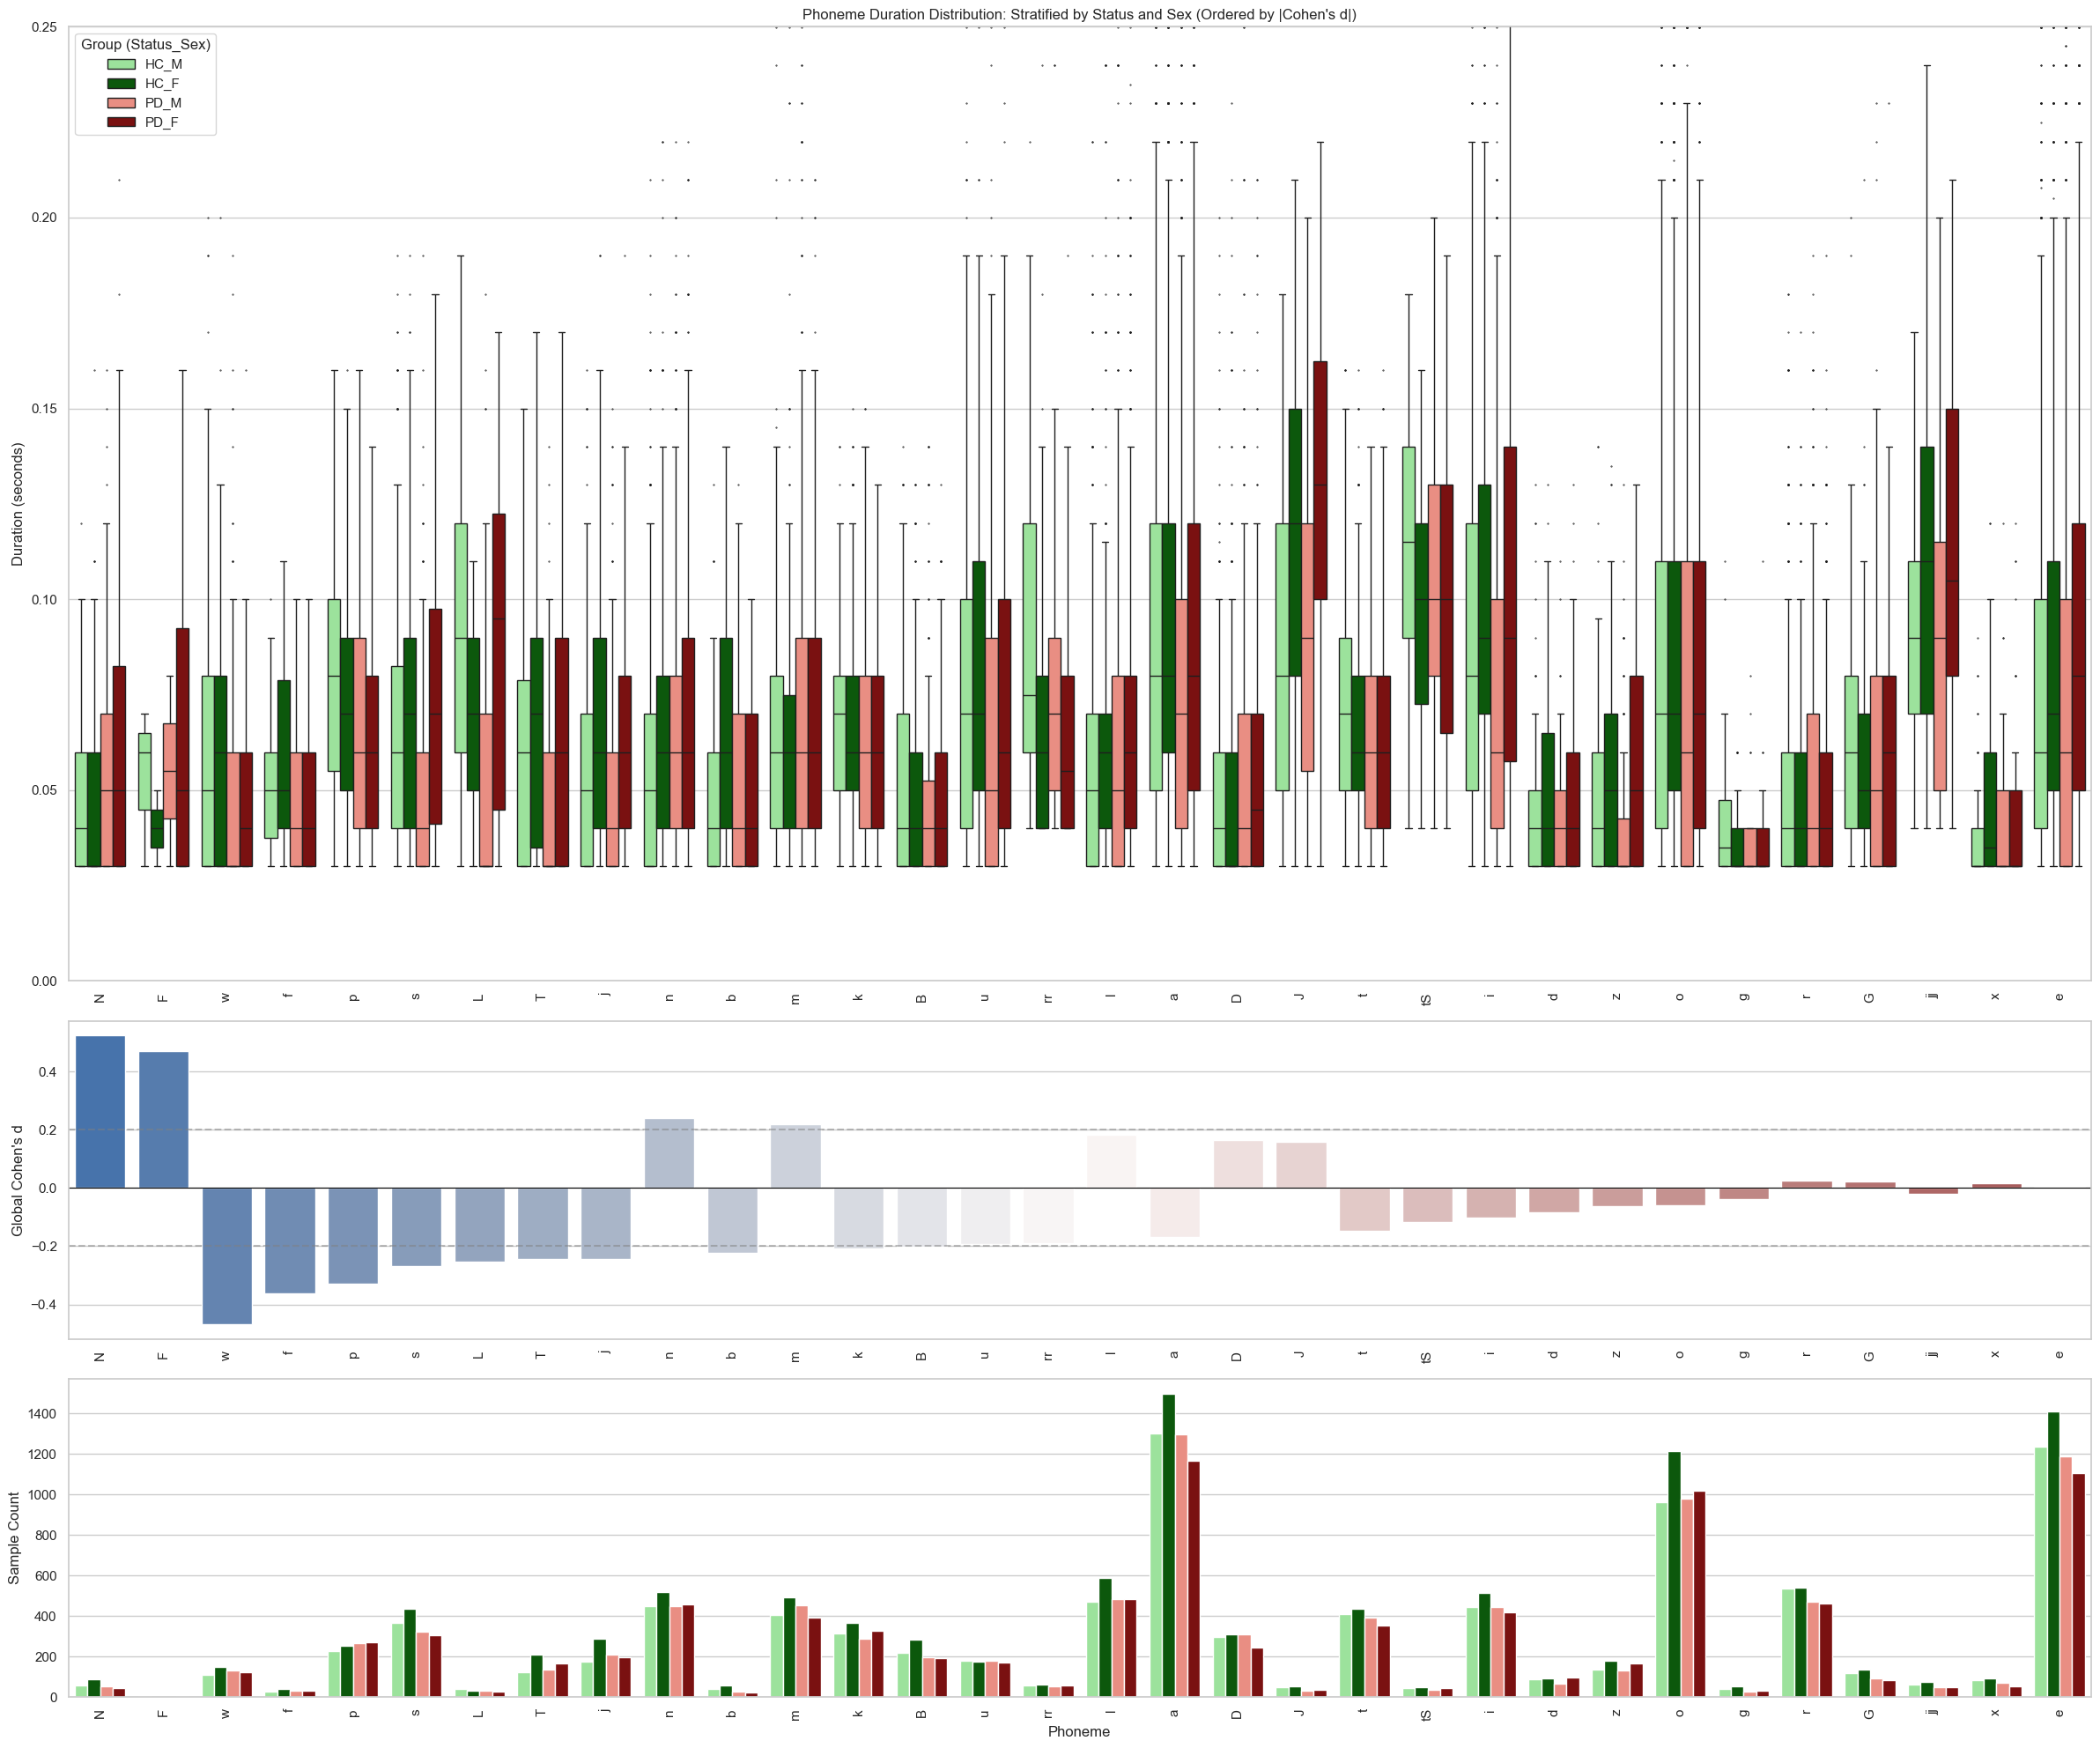

Generating plots for task: readtext_split


a:\work\FAU\dysarthric-TTS\phoneme_evaluation\visualizer.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_stats, x="phoneme", y="cohens_d", ax=ax_d, palette="vlag")


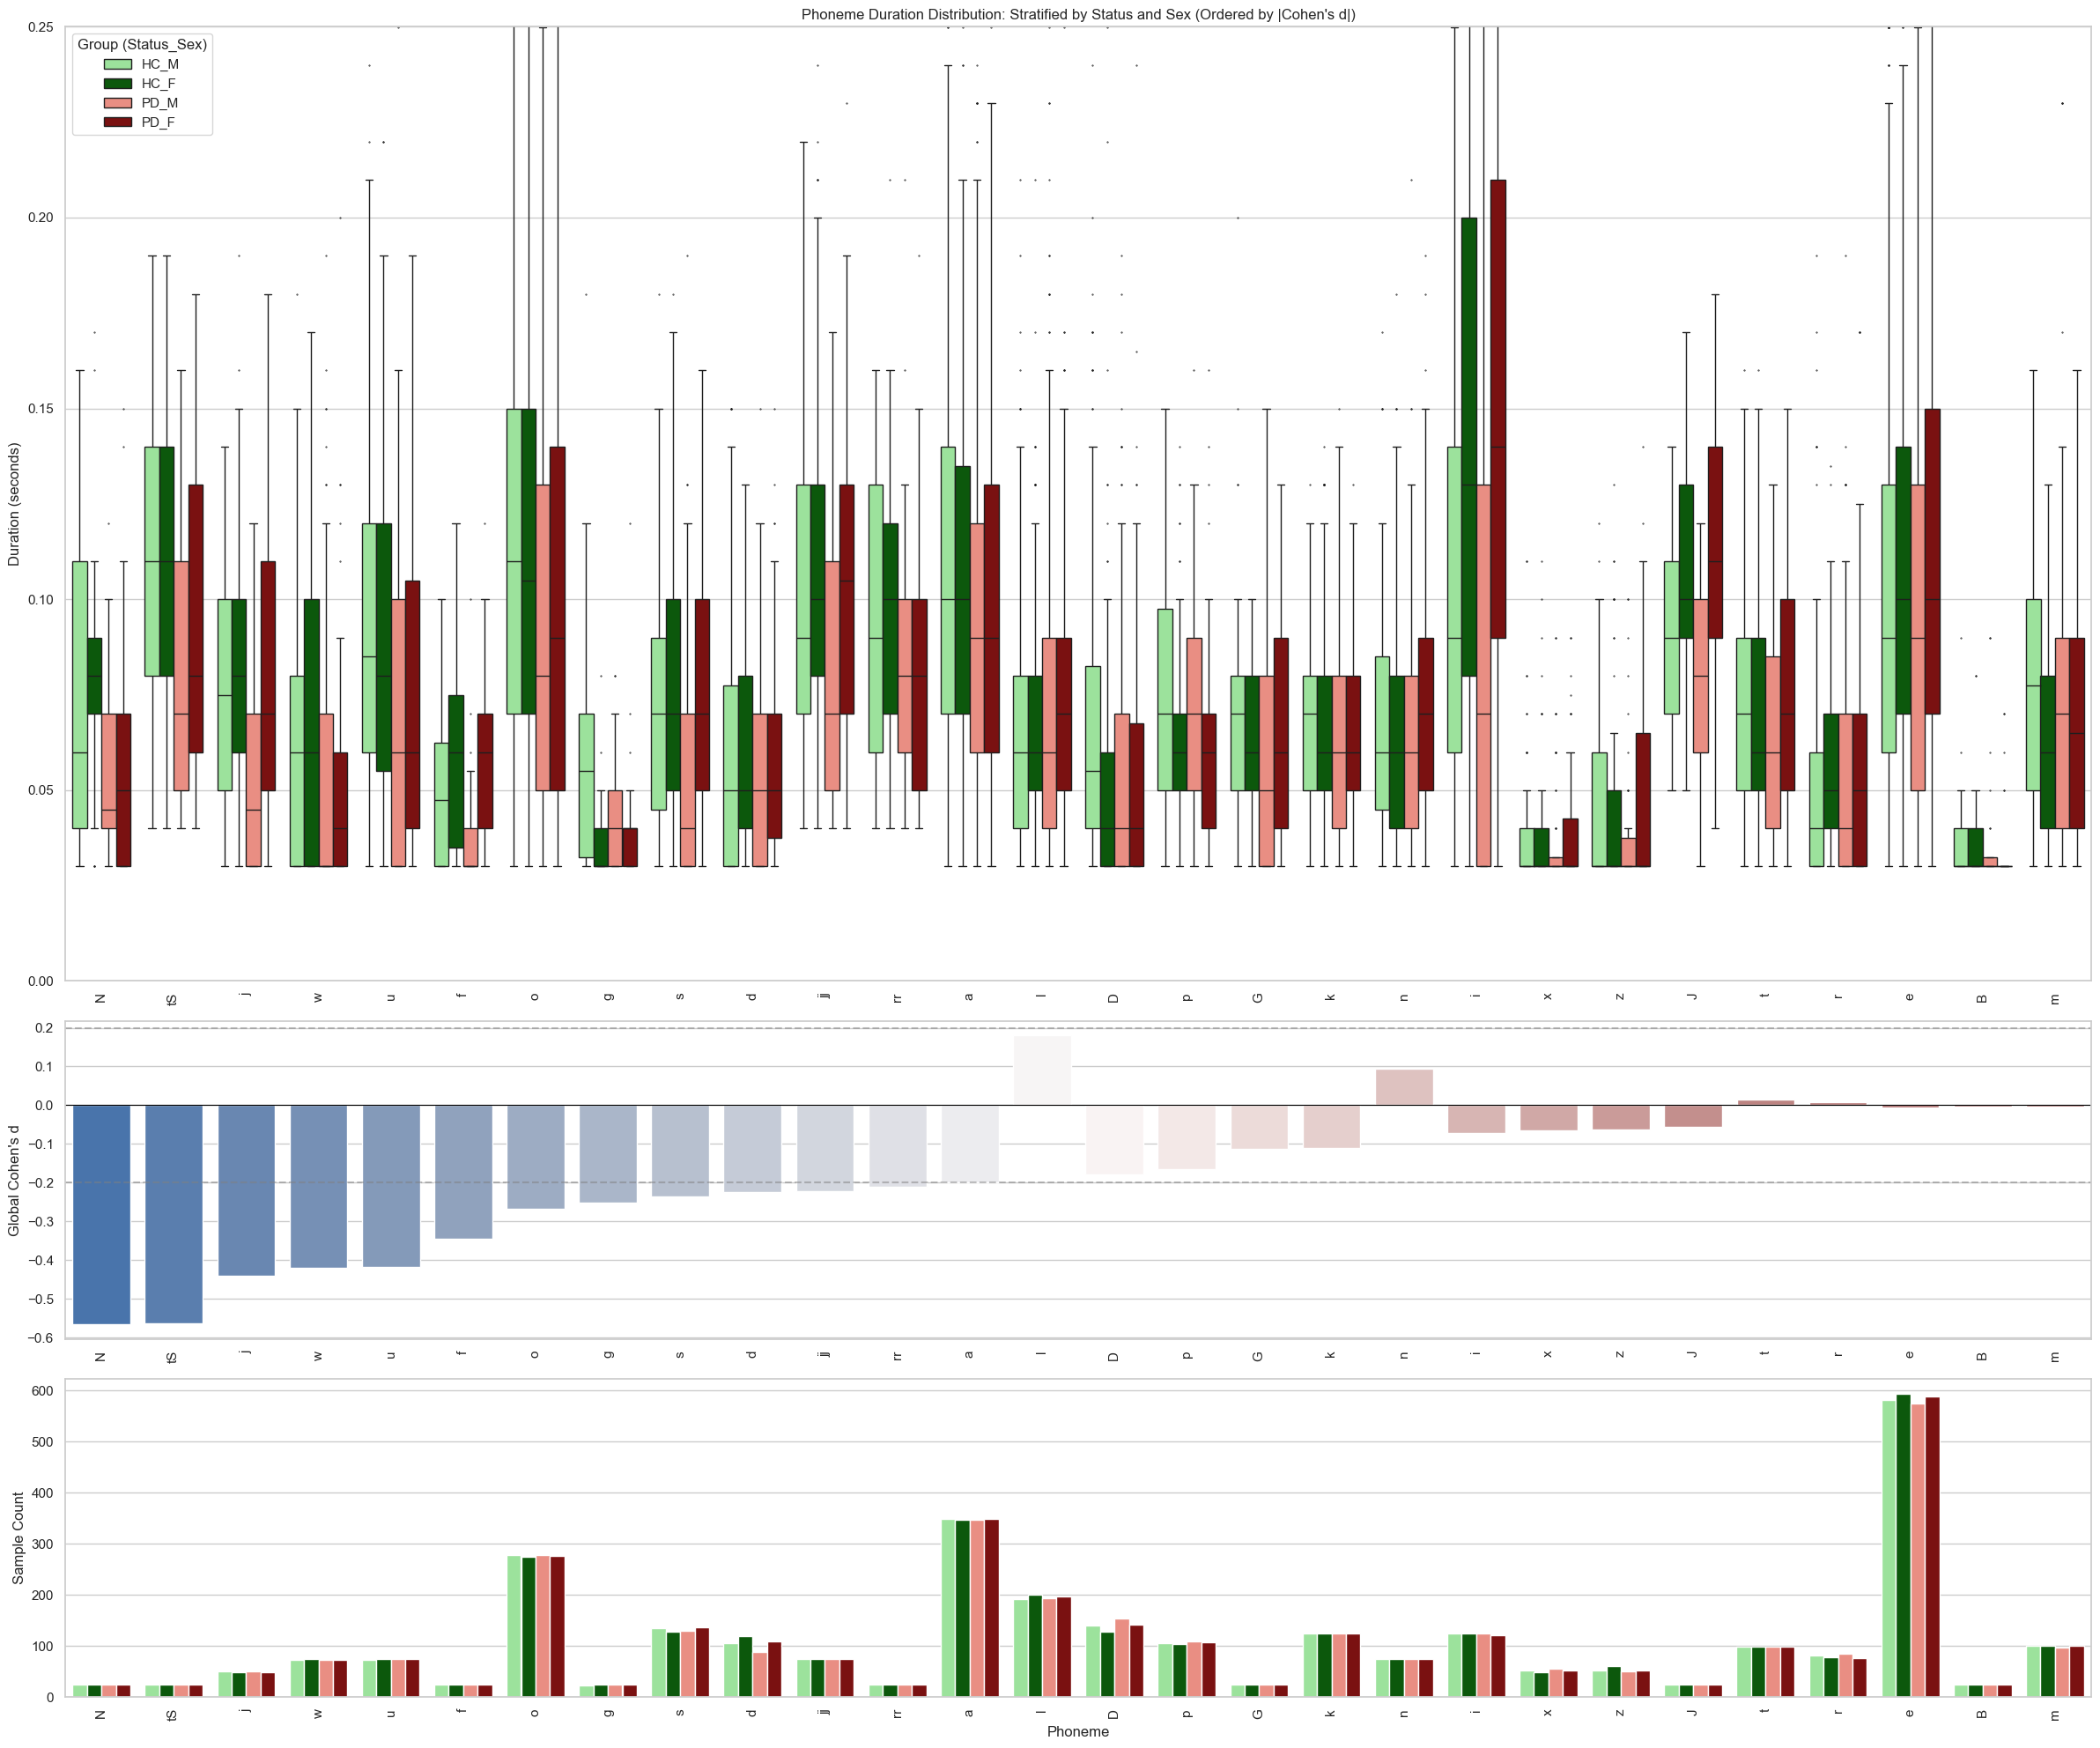

Generating plots for task: sentences_cleaned


a:\work\FAU\dysarthric-TTS\phoneme_evaluation\visualizer.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_stats, x="phoneme", y="cohens_d", ax=ax_d, palette="vlag")


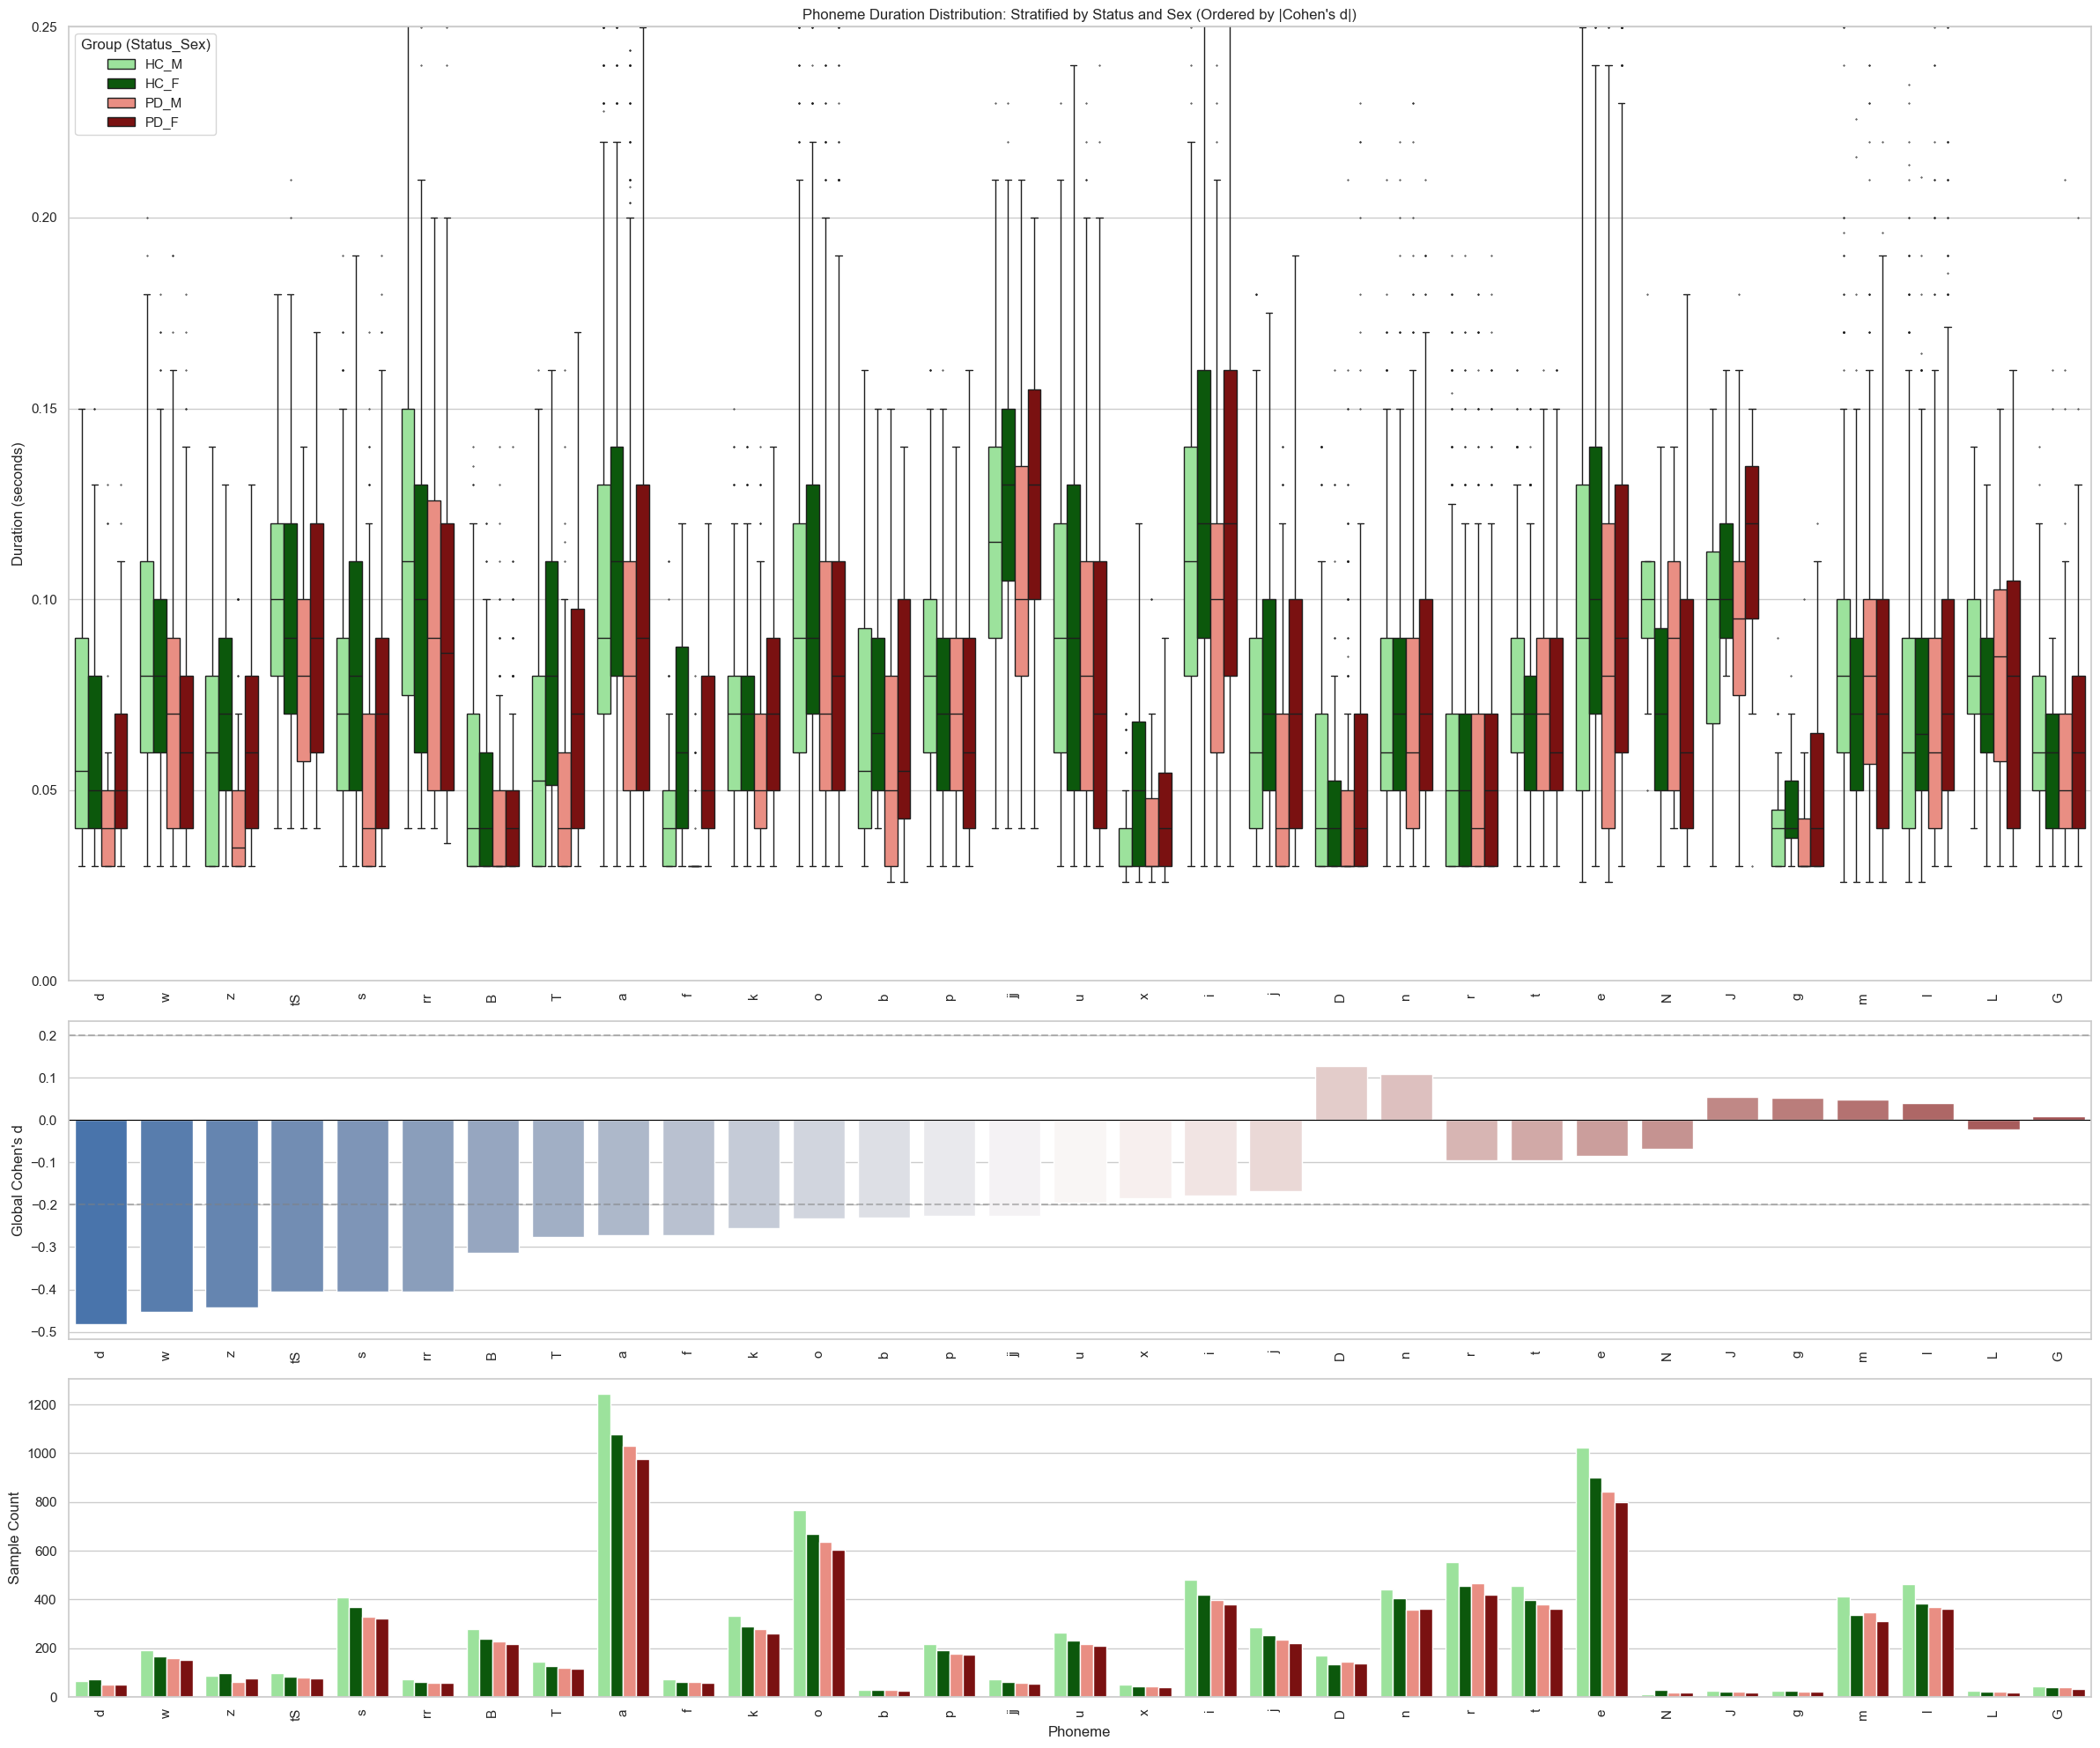

Generating plots for task: words_merged


a:\work\FAU\dysarthric-TTS\phoneme_evaluation\visualizer.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_stats, x="phoneme", y="cohens_d", ax=ax_d, palette="vlag")


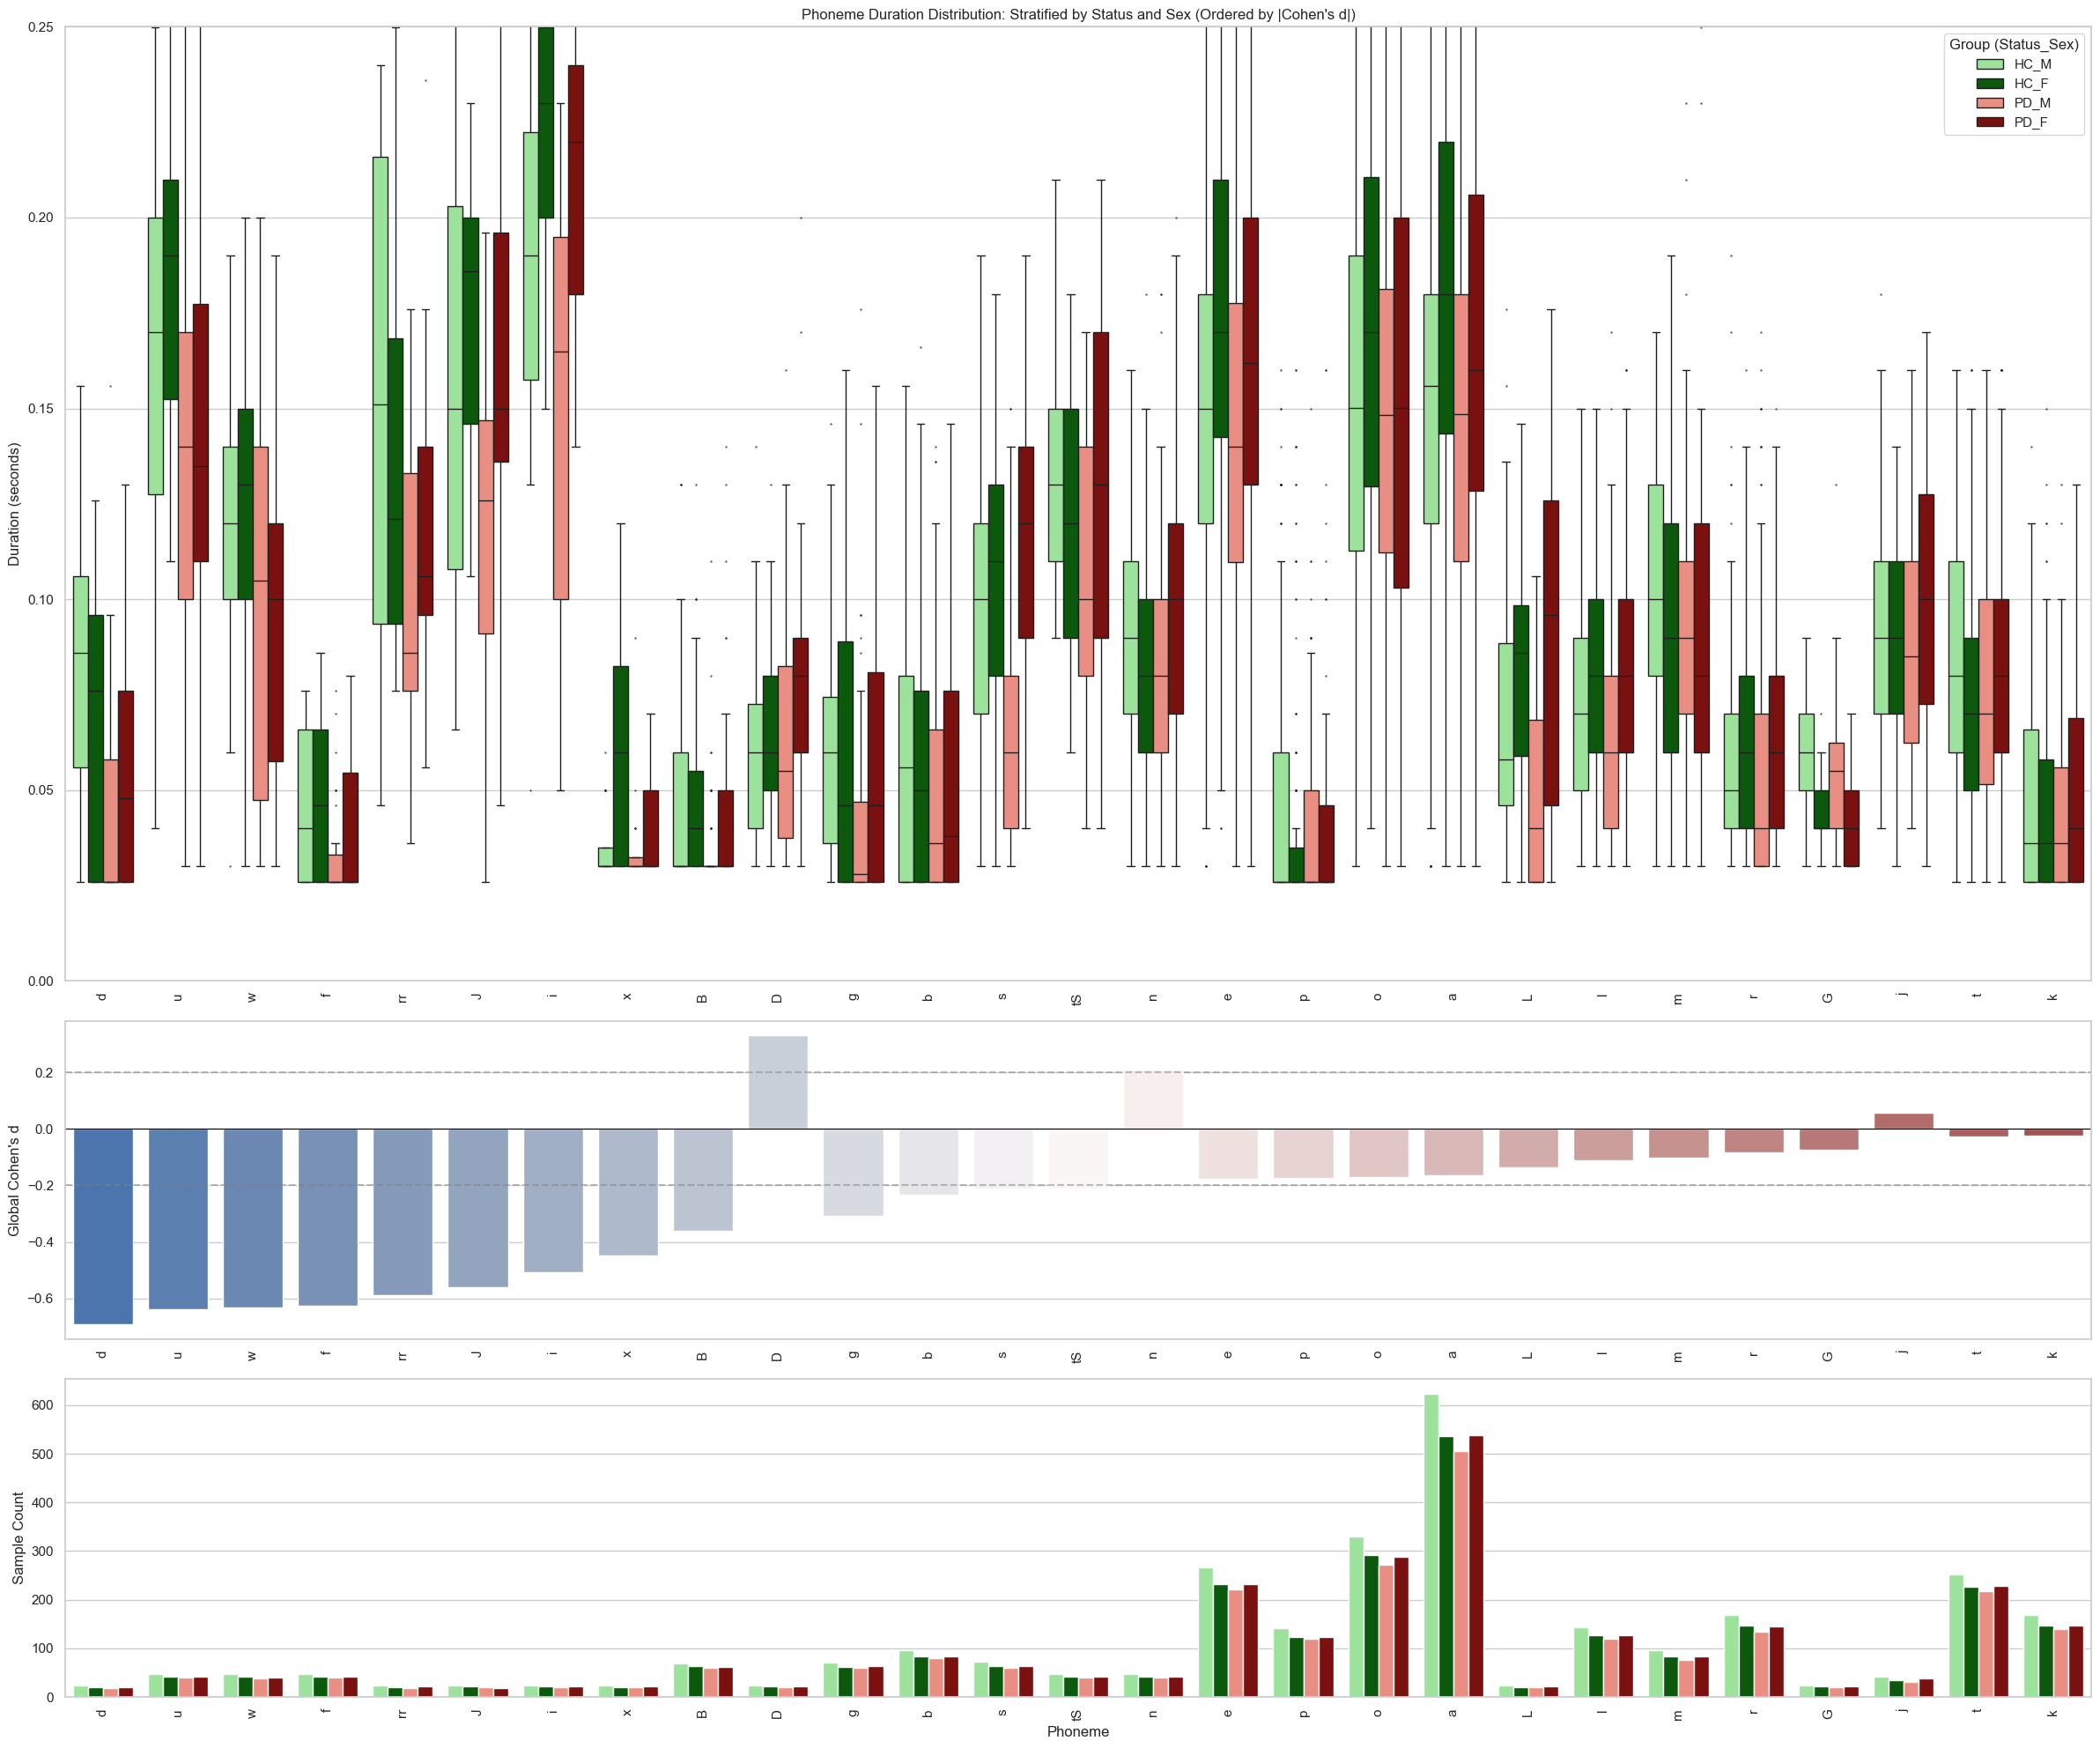

In [11]:
from phoneme_evaluation.visualizer import plot_stratified_phonemes_boxplot
from phoneme_evaluation.constants import TASKS
from IPython.display import Image, display
from pathlib import Path

df_clean = load_all_data(filter_technical=True)

for task in TASKS:
    task_df = df_clean[df_clean['task'] == task]
    if task_df.empty: 
        print(f'No data for task: {task}')
        continue
        
    print(f'Generating plots for task: {task}')
    plot_path = Path(f'../reports/plots/phonemes_stratified_{task}.png')
    plot_stratified_phonemes_boxplot(task_df, plot_path)
    
    # Safety check: only display if the file was created
    if plot_path.exists():
        display(Image(filename=str(plot_path)))
    else:
        print(f'Skipping display for {task} (plot not generated due to insufficient data)')